In [18]:
print(h1_rb.values())          # 리빈된 bin content
print(h1_rb.variances())       # variance (sqrt 하면 error)
print(h1_rb.axes[0].edges)     # 새 bin edges

[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 1.40289083e-01 2.09016274e-01 2.54492315e-01 2.53828001e-01
 3.00235949e-01 2.80734058e-01 2.78765021e-01 2.72003845e-01
 2.93288675e-01 3.15548068e-01 3.80294402e-01 4.41710074e-01
 6.24395264e-01 9.17299274e-01 2.05667429e+00 4.57728050e+00
 3.89069779e+00 1.33804508e+00 3.70014521e-01 1.22144402e-01
 4.03910856e-02 2.62235739e-02 1.28218455e-02 7.15556044e-03
 5.52489695e-03 2.70820831e-03 1.85624938e-03 1.00084466e-03
 6.20231032e-04 8.92286072e-04 9.98479896e-04 0.00000000e+00
 1.02593840e-03 0.00000000e+00 0.00000000e+00 1.02908227e-04]
[0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 9.67503584e-05 1.44662742e-04 1.81963034e-04 1.78558824e-04
 2.17972147e-04 2.01633251e-04 2.00220984e-04 2.01345954e-04
 2.07374710e-04 2.27818008e-04 2.75778684e-04 3.15174370e-04
 4.56777296e-04 6.59574073e-04 1.49439091e-03 3.35085740e-03
 2.84365991e-03 9.67209594e-04 2.71682881e-04 9.40648358e-05
 2.77974481e-05 2.09434

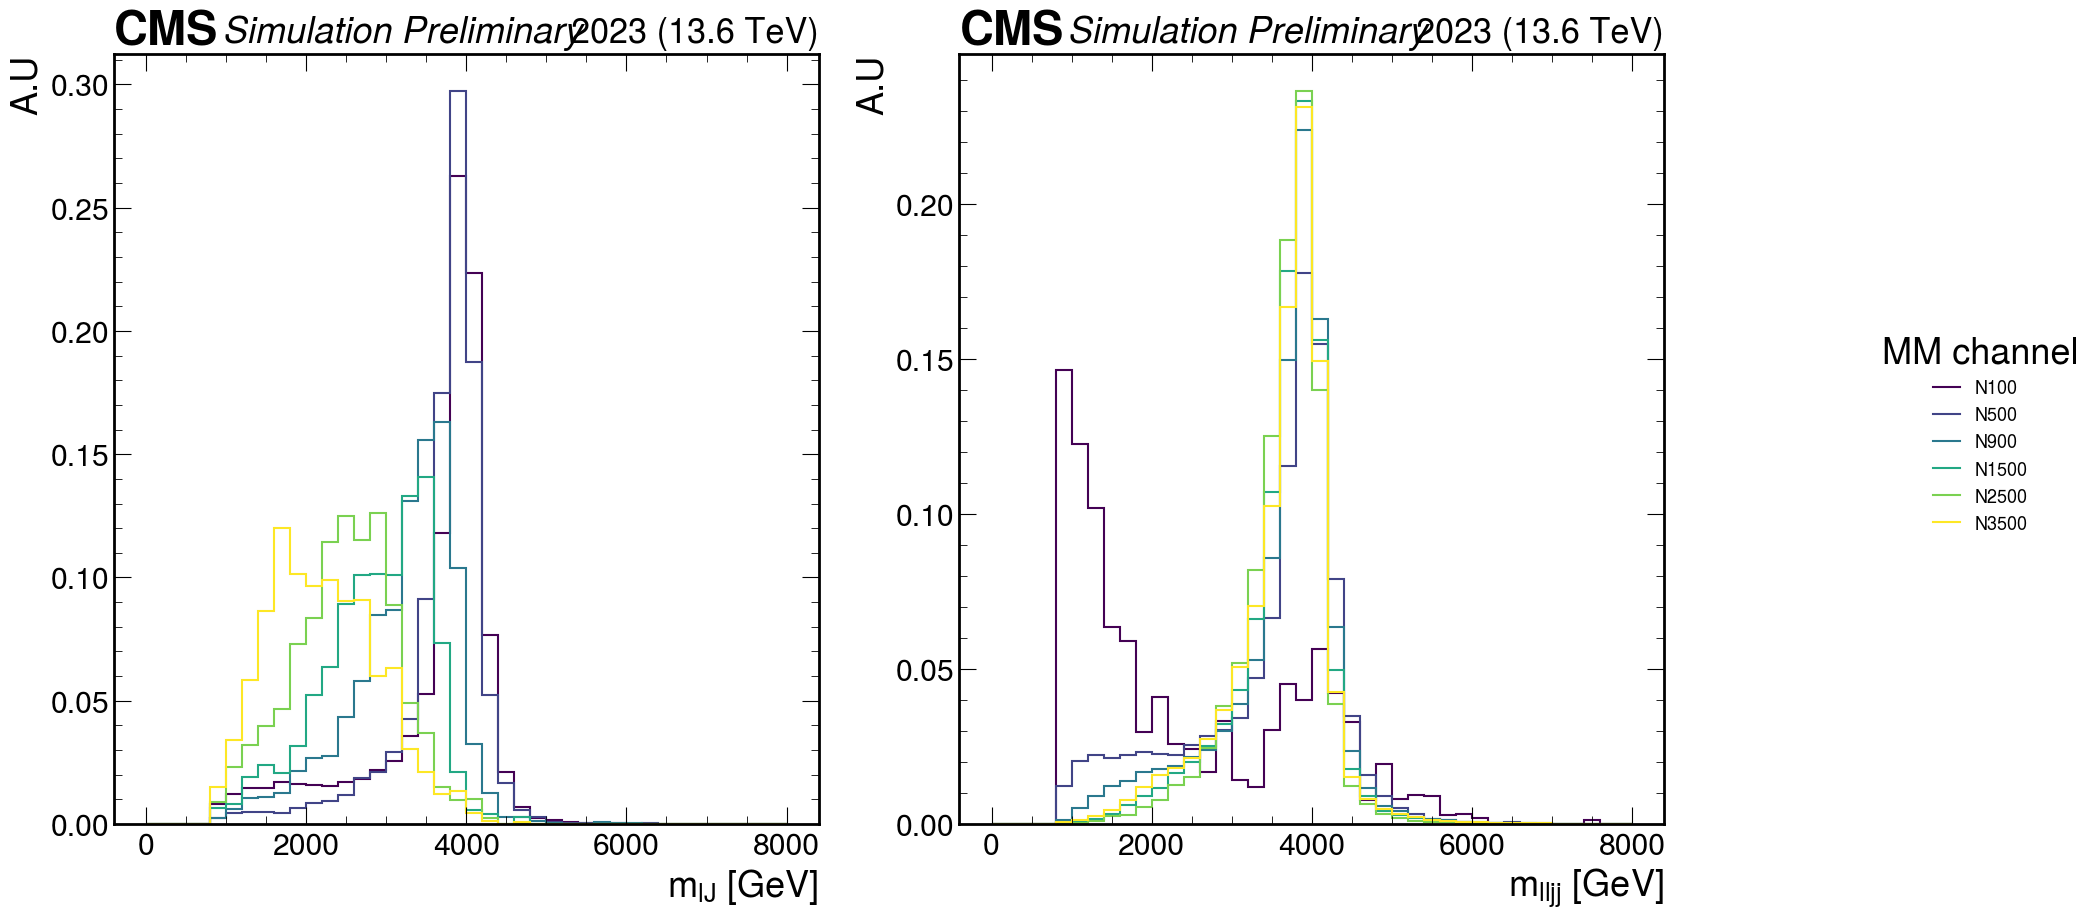

In [2]:
import uproot
import hist
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mplhep as hep

hep.style.use("CMS")

base_dir = "/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002_copy/2023/sig"
#n_values = range(100, 4000, 200)
n_values = [100, 500, 900, 1500, 2500, 3500]
#range(100, 4000, 200)

cmap = plt.cm.viridis
colors = cmap(np.linspace(0, 1, len(n_values)))


def draw_panel(ax, branch, xlabel):
    for n, color in zip(n_values, colors):
        fpath = f"{base_dir}/WR4000N{n}MM.root"

        f = uproot.open(fpath)
        h = f[branch].to_hist()
        h_rb = h[::hist.rebin(200)]

        vals  = h_rb.values()
        edges = h_rb.axes[0].edges
        integral = vals.sum()

        if integral == 0:
            print(f"skip N{n}: empty histogram ({branch})")
            continue

        vals_norm = vals / integral

        hep.histplot(
            vals_norm,
            bins=edges,
            ax=ax,
            histtype="step",
            color=mcolors.to_hex(color),
            linewidth=1.5,
            label=f"N{n}",
        )

    hep.cms.label("Preliminary", data=False, year=2023, com=13.6, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("A.U")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

draw_panel(ax1, "Central/SR_Boosted_MM_mlljj",  r"$m_{lJ}$ [GeV]")
draw_panel(ax2, "Central/SR_Resolved_MM_mlljj", r"$m_{lljj}$ [GeV]")

# 한쪽 ax에서 handle/label을 뽑아 figure 공통 legend로
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),   # figure 오른쪽 바깥
    ncol=1,
    fontsize=13,
    title="MM channel",
)

fig.savefig(
    "SR_MM_norm_scan_boosted_resolved.png",
    dpi=150,
    bbox_inches="tight",          # 바깥 legend 잘림 방지
)
plt.show()

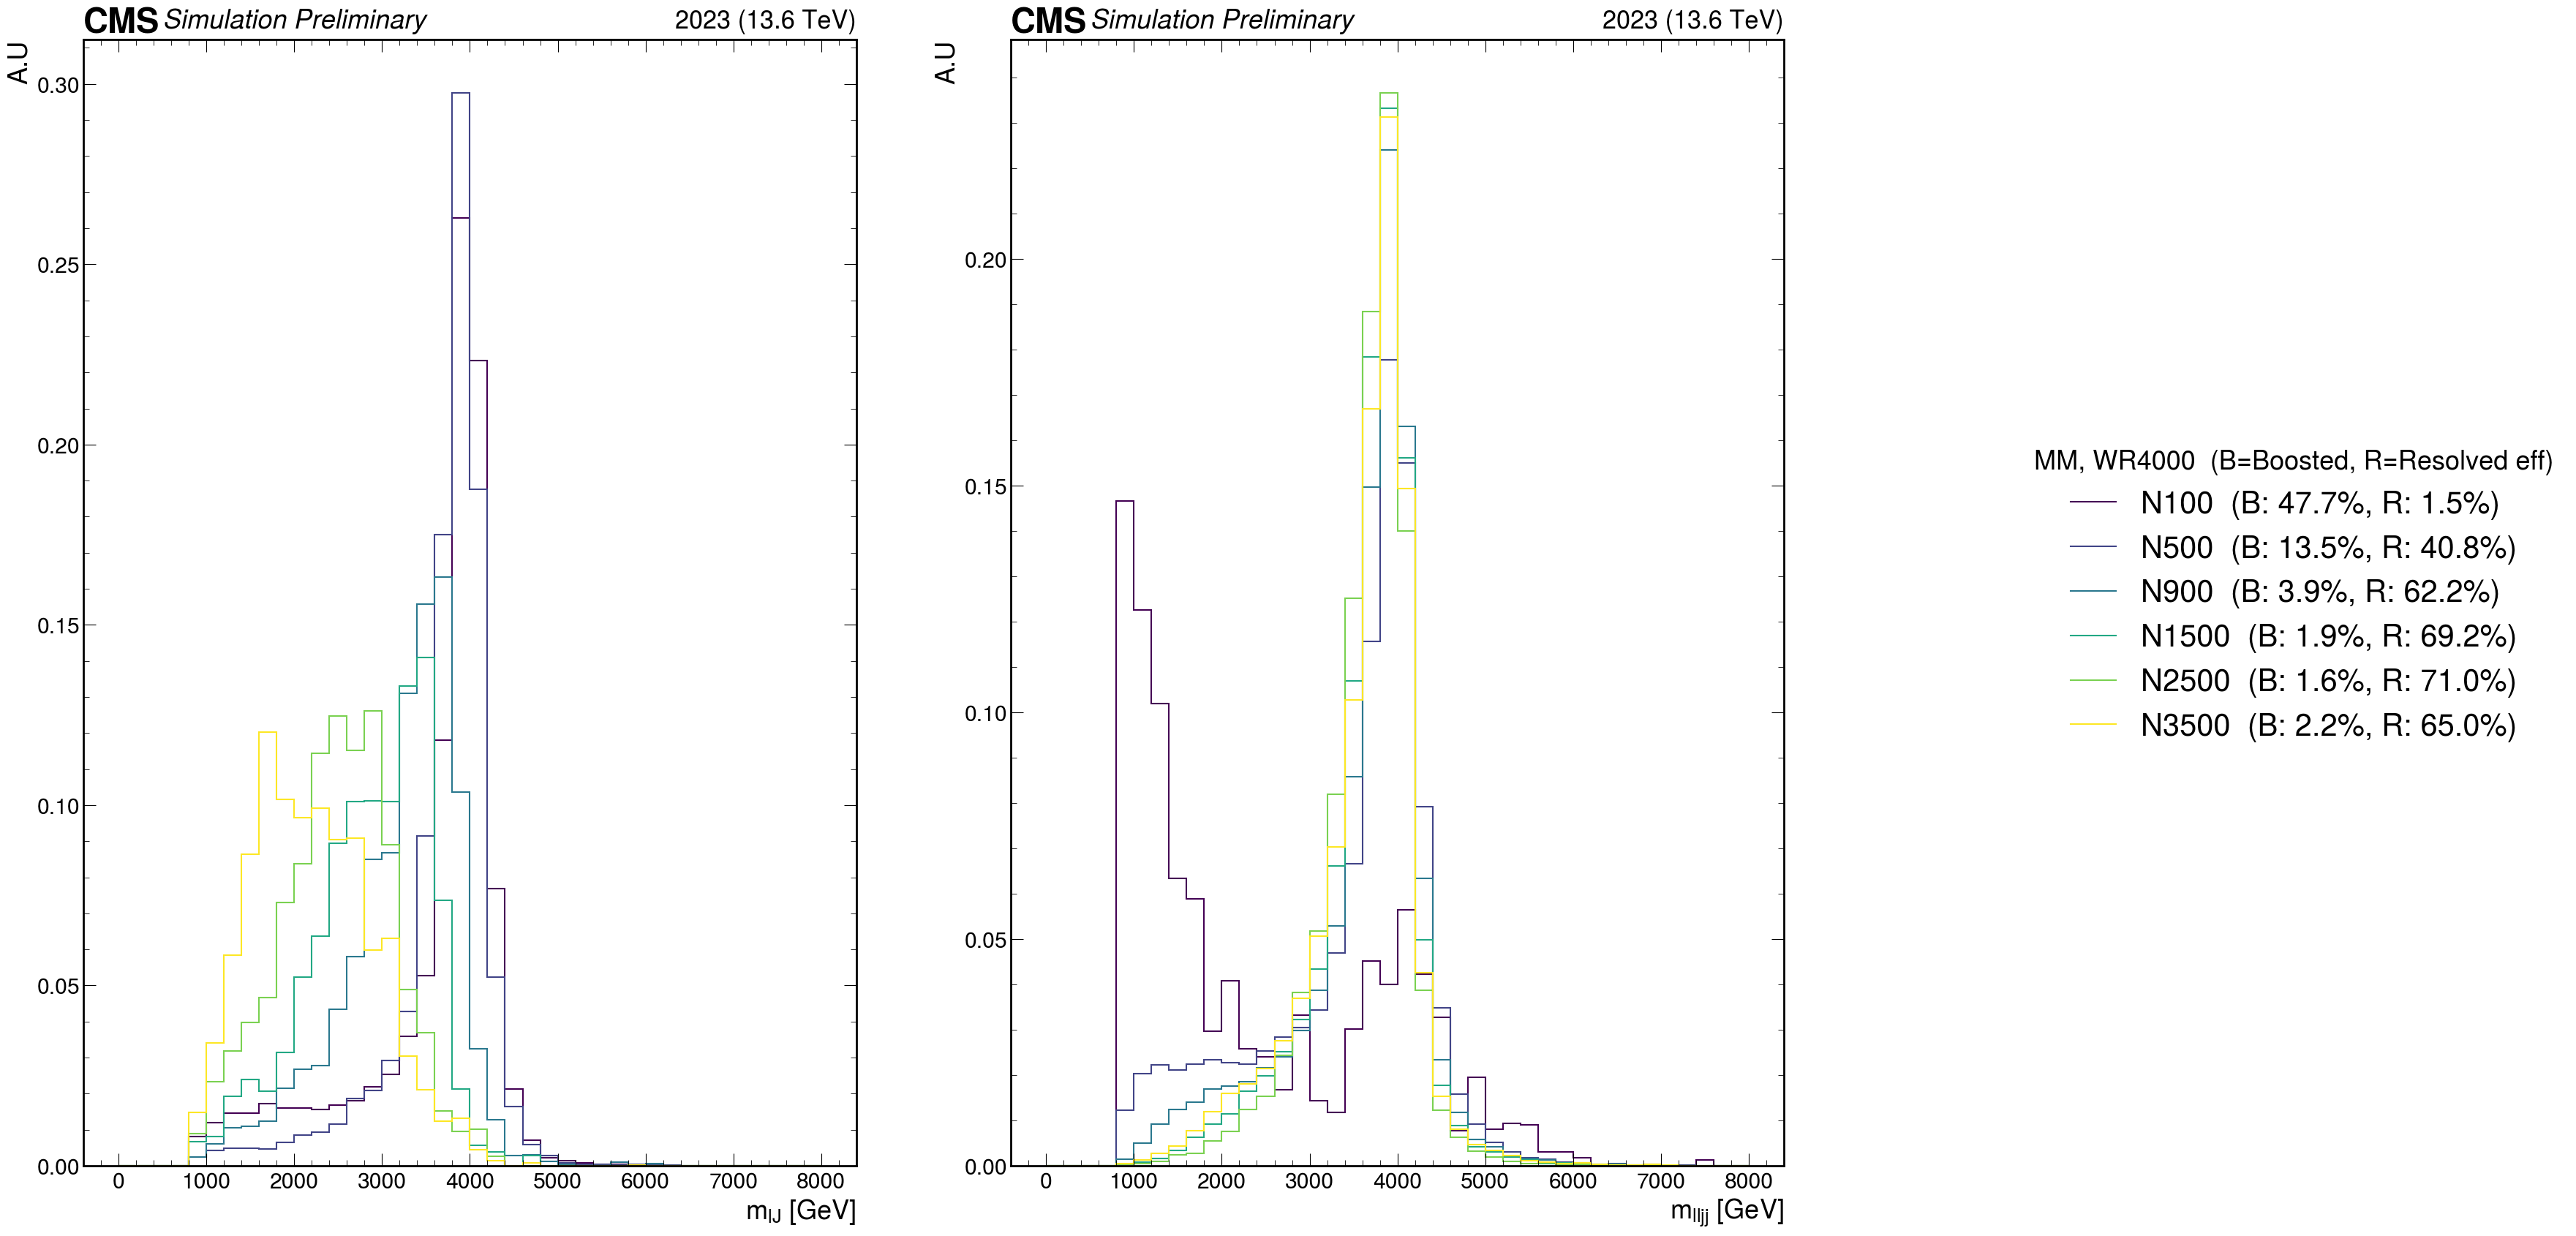

In [3]:
import json
import re
from pathlib import Path

import uproot
import hist
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mplhep as hep

hep.style.use("CMS")

base_dir = "/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002_copy/2023/sig"
n_values = [100, 500, 900, 1500, 2500, 3500]
WR_FIXED = 4000

cmap = plt.cm.viridis
colors_arr = cmap(np.linspace(0, 1, len(n_values)))

# ---- efficiency 추출 (cutflow 기반) ----
boosted_hist_candidates = [
    'Central/Cutflow_for_Boosted_SR',
]
resolved_hist_candidates = [
    'Central/Cutflow_for_Resolved_SR',
    'Central/Cutflow_for_reseolved_SR',
]

def extract_efficiency_from_cutflow(root_path, hist_candidates, use_penultimate_bin=False):
    with uproot.open(root_path) as root_file:
        hist_name = next((name for name in hist_candidates if name in root_file), None)
        if hist_name is None:
            return np.nan

        values = root_file[hist_name].values(flow=False)
        if len(values) < 2:
            return np.nan

        second_bin = float(values[1])
        numerator_bin = float(values[-2] if use_penultimate_bin else values[-1])
        return np.nan if second_bin <= 0 else numerator_bin / second_bin

def get_eff(n, region):
    """N별 root 파일에서 boosted/resolved efficiency를 직접 읽는다."""
    fpath = f"{base_dir}/WR{WR_FIXED}N{n}MM.root"
    try:
        if region == "boosted":
            return extract_efficiency_from_cutflow(fpath, boosted_hist_candidates, use_penultimate_bin=True)
        else:
            return extract_efficiency_from_cutflow(fpath, resolved_hist_candidates)
    except (FileNotFoundError, OSError):
        return np.nan

def make_label(n):
    eff_b = get_eff(n, "boosted")
    eff_r = get_eff(n, "resolved")
    b_str = "-" if np.isnan(eff_b) else f"{eff_b*100:.1f}%"
    r_str = "-" if np.isnan(eff_r) else f"{eff_r*100:.1f}%"
    return f"N{n}  (B: {b_str}, R: {r_str})"

# ---- plot ----
def draw_panel(ax, branch, xlabel):
    for n, color in zip(n_values, colors_arr):
        fpath = f"{base_dir}/WR{WR_FIXED}N{n}MM.root"

        f = uproot.open(fpath)
        h = f[branch].to_hist()
        h_rb = h[::hist.rebin(200)]

        vals  = h_rb.values()
        edges = h_rb.axes[0].edges
        integral = vals.sum()

        if integral == 0:
            print(f"skip N{n}: empty histogram ({branch})")
            continue

        vals_norm = vals / integral

        hep.histplot(
            vals_norm,
            bins=edges,
            ax=ax,
            histtype="step",
            color=mcolors.to_hex(color),
            linewidth=1.5,
            label=make_label(n),
        )

    hep.cms.label("Preliminary", data=False, year=2023, com=13.6, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("A.U")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 20))

draw_panel(ax1, "Central/SR_Boosted_MM_mlljj",  r"$m_{lJ}$ [GeV]")
draw_panel(ax2, "Central/SR_Resolved_MM_mlljj", r"$m_{lljj}$ [GeV]")

handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    ncol=1,
    fontsize=30,
    title="MM, WR4000  (B=Boosted, R=Resolved eff)",
)

fig.savefig(
    "SR_MM_norm_scan_boosted_resolved_eff.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

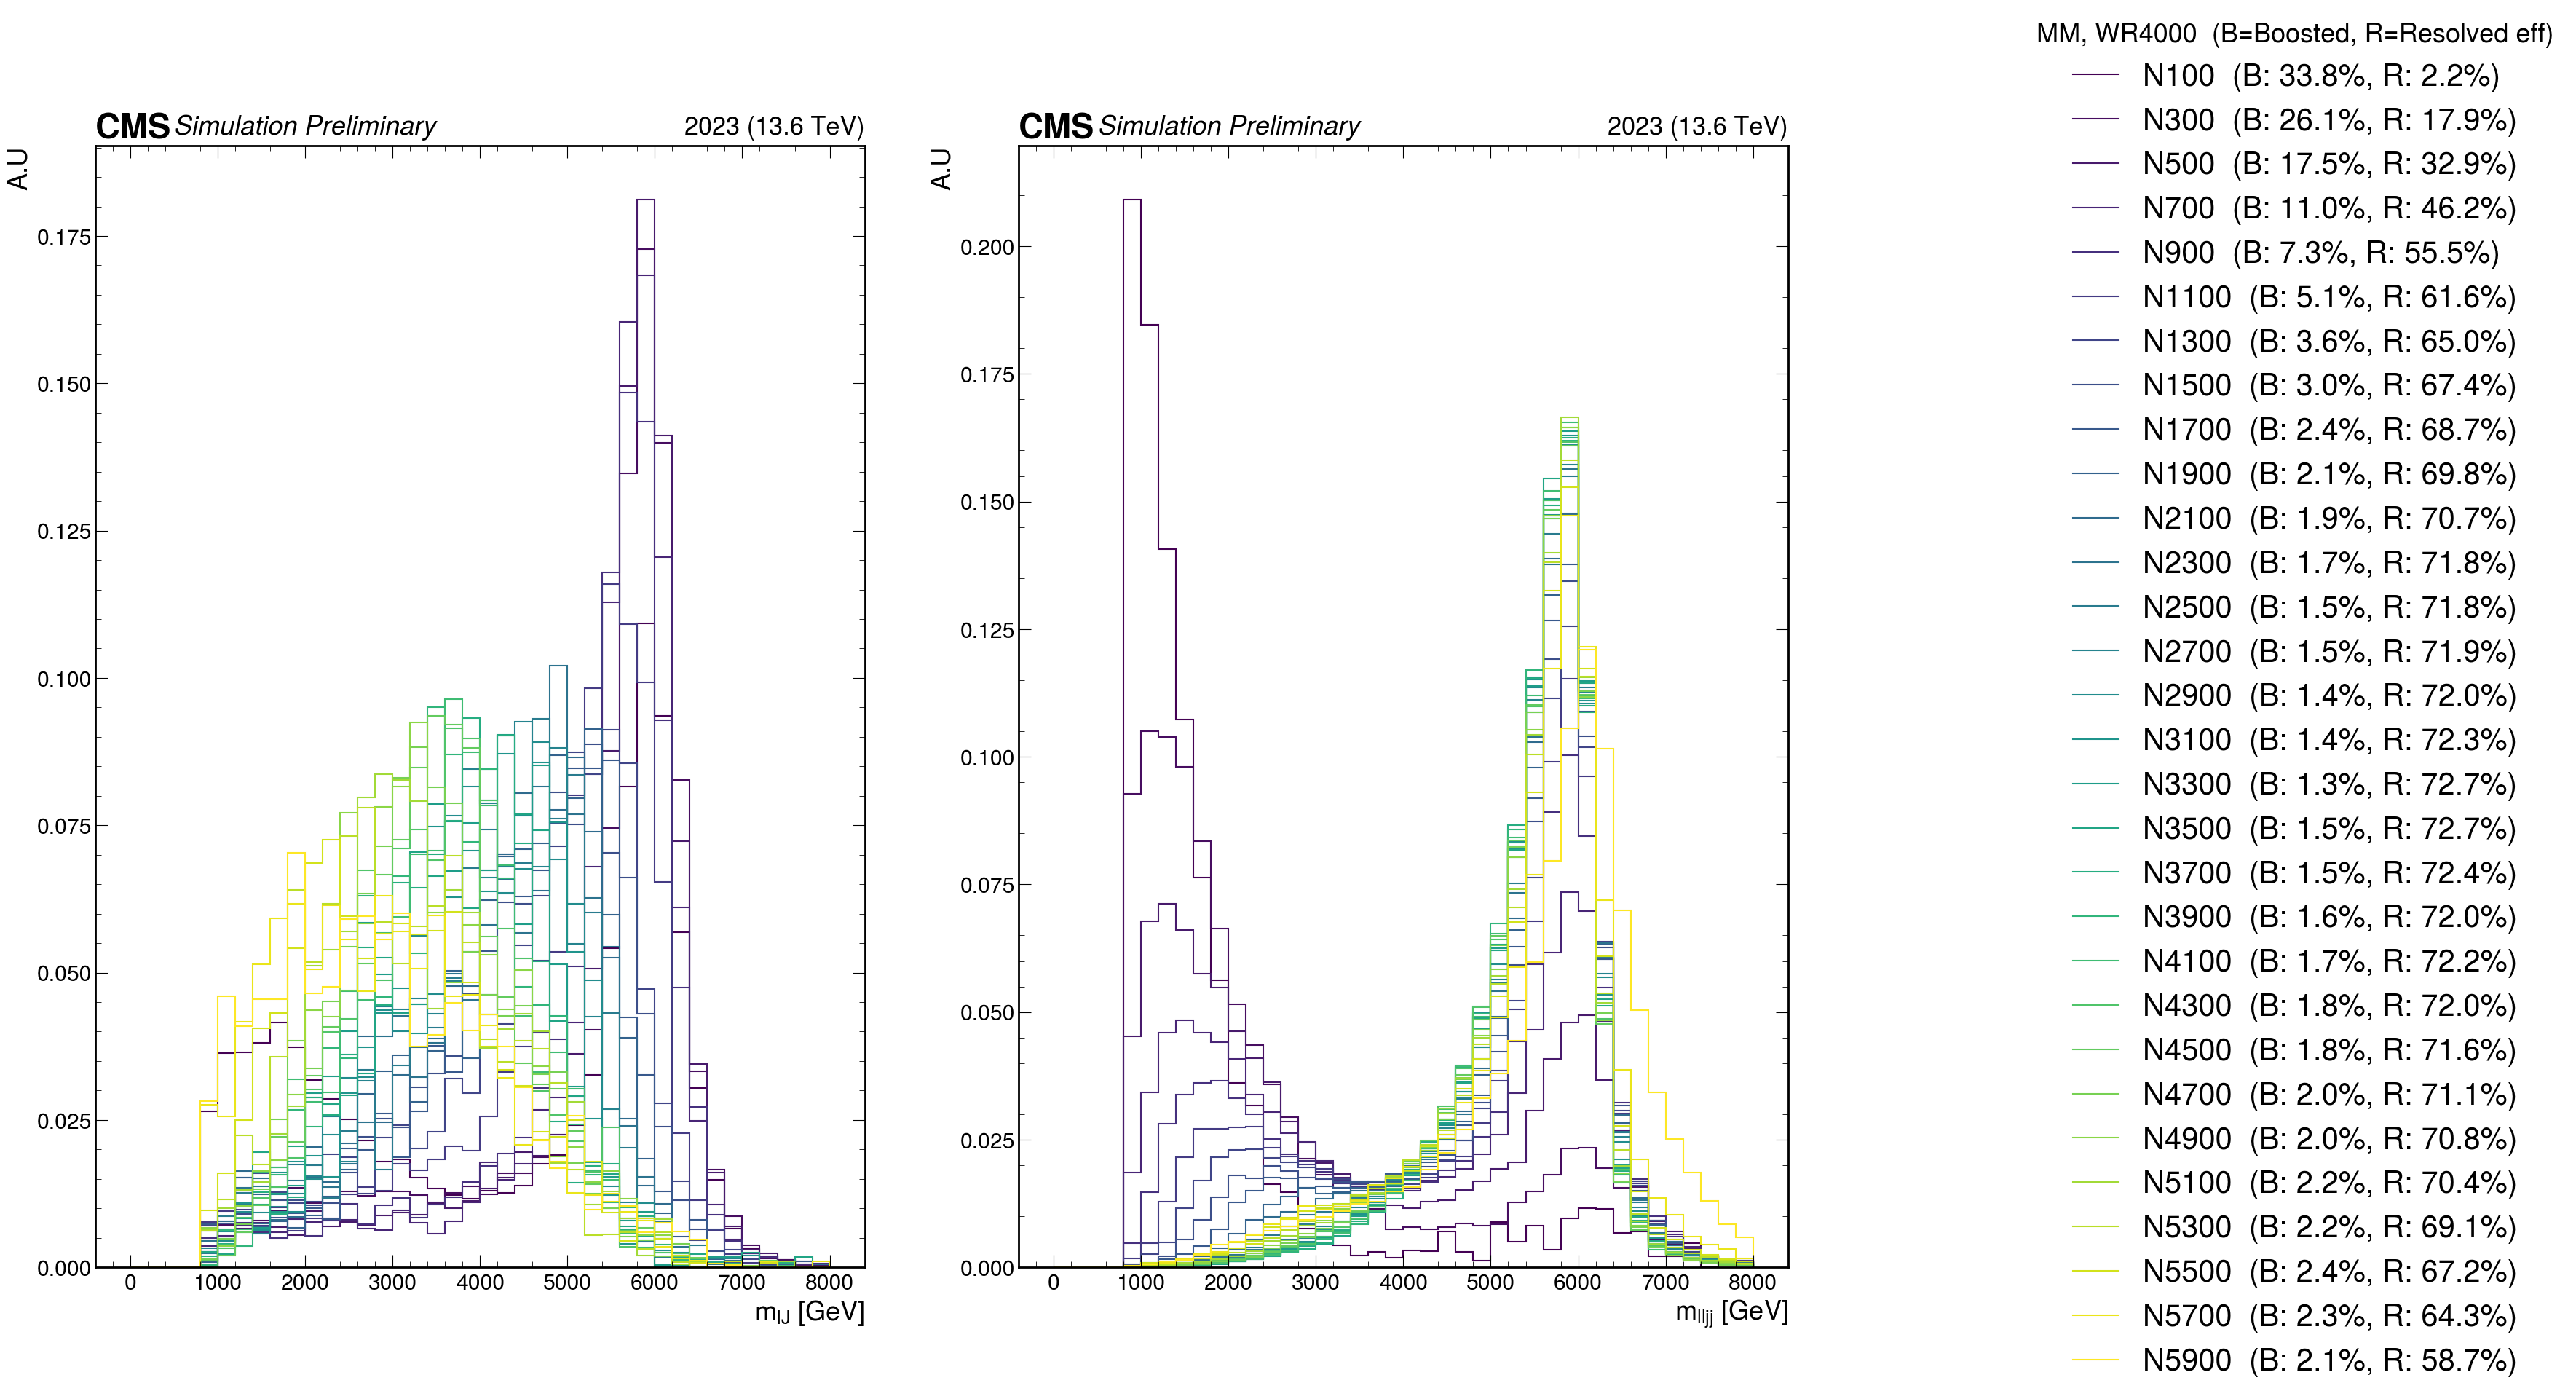

In [49]:
import json
import re
from pathlib import Path

import uproot
import hist
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mplhep as hep

hep.style.use("CMS")

base_dir = "/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002_copy/2023"
n_values = range(100, 6000, 200)
WR_FIXED = 6000

cmap = plt.cm.viridis
colors_arr = cmap(np.linspace(0, 1, len(n_values)))

# ---- efficiency 추출 (cutflow 기반) ----
boosted_hist_candidates = [
    'Central/Cutflow_for_Boosted_SR',
]
resolved_hist_candidates = [
    'Central/Cutflow_for_Resolved_SR',
    'Central/Cutflow_for_reseolved_SR',
]

def extract_efficiency_from_cutflow(root_path, hist_candidates, use_penultimate_bin=False):
    with uproot.open(root_path) as root_file:
        hist_name = next((name for name in hist_candidates if name in root_file), None)
        if hist_name is None:
            return np.nan

        values = root_file[hist_name].values(flow=False)
        if len(values) < 2:
            return np.nan

        second_bin = float(values[1])
        numerator_bin = float(values[-2] if use_penultimate_bin else values[-1])
        return np.nan if second_bin <= 0 else numerator_bin / second_bin

def get_eff(n, region):
    """N별 root 파일에서 boosted/resolved efficiency를 직접 읽는다."""
    fpath = f"{base_dir}/WR{WR_FIXED}N{n}MM.root"
    try:
        if region == "boosted":
            return extract_efficiency_from_cutflow(fpath, boosted_hist_candidates, use_penultimate_bin=True)
        else:
            return extract_efficiency_from_cutflow(fpath, resolved_hist_candidates)
    except (FileNotFoundError, OSError):
        return np.nan

def make_label(n):
    eff_b = get_eff(n, "boosted")
    eff_r = get_eff(n, "resolved")
    b_str = "-" if np.isnan(eff_b) else f"{eff_b*100:.1f}%"
    r_str = "-" if np.isnan(eff_r) else f"{eff_r*100:.1f}%"
    return f"N{n}  (B: {b_str}, R: {r_str})"

# ---- plot ----
def draw_panel(ax, branch, xlabel):
    for n, color in zip(n_values, colors_arr):
        fpath = f"{base_dir}/WR{WR_FIXED}N{n}MM.root"

        f = uproot.open(fpath)
        h = f[branch].to_hist()
        h_rb = h[::hist.rebin(200)]

        vals  = h_rb.values()
        edges = h_rb.axes[0].edges
        integral = vals.sum()

        if integral == 0:
            print(f"skip N{n}: empty histogram ({branch})")
            continue

        vals_norm = vals / integral

        hep.histplot(
            vals_norm,
            bins=edges,
            ax=ax,
            histtype="step",
            color=mcolors.to_hex(color),
            linewidth=1.5,
            label=make_label(n),
        )

    hep.cms.label("Preliminary", data=False, year=2023, com=13.6, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("A.U")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 20))

draw_panel(ax1, "Central/SR_Boosted_MM_mlljj",  r"$m_{lJ}$ [GeV]")
draw_panel(ax2, "Central/SR_Resolved_MM_mlljj", r"$m_{lljj}$ [GeV]")

handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    ncol=1,
    fontsize=30,
    title="MM, WR4000  (B=Boosted, R=Resolved eff)",
)

fig.savefig(
    "SR_MM_norm_scan_boosted_resolved_eff.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

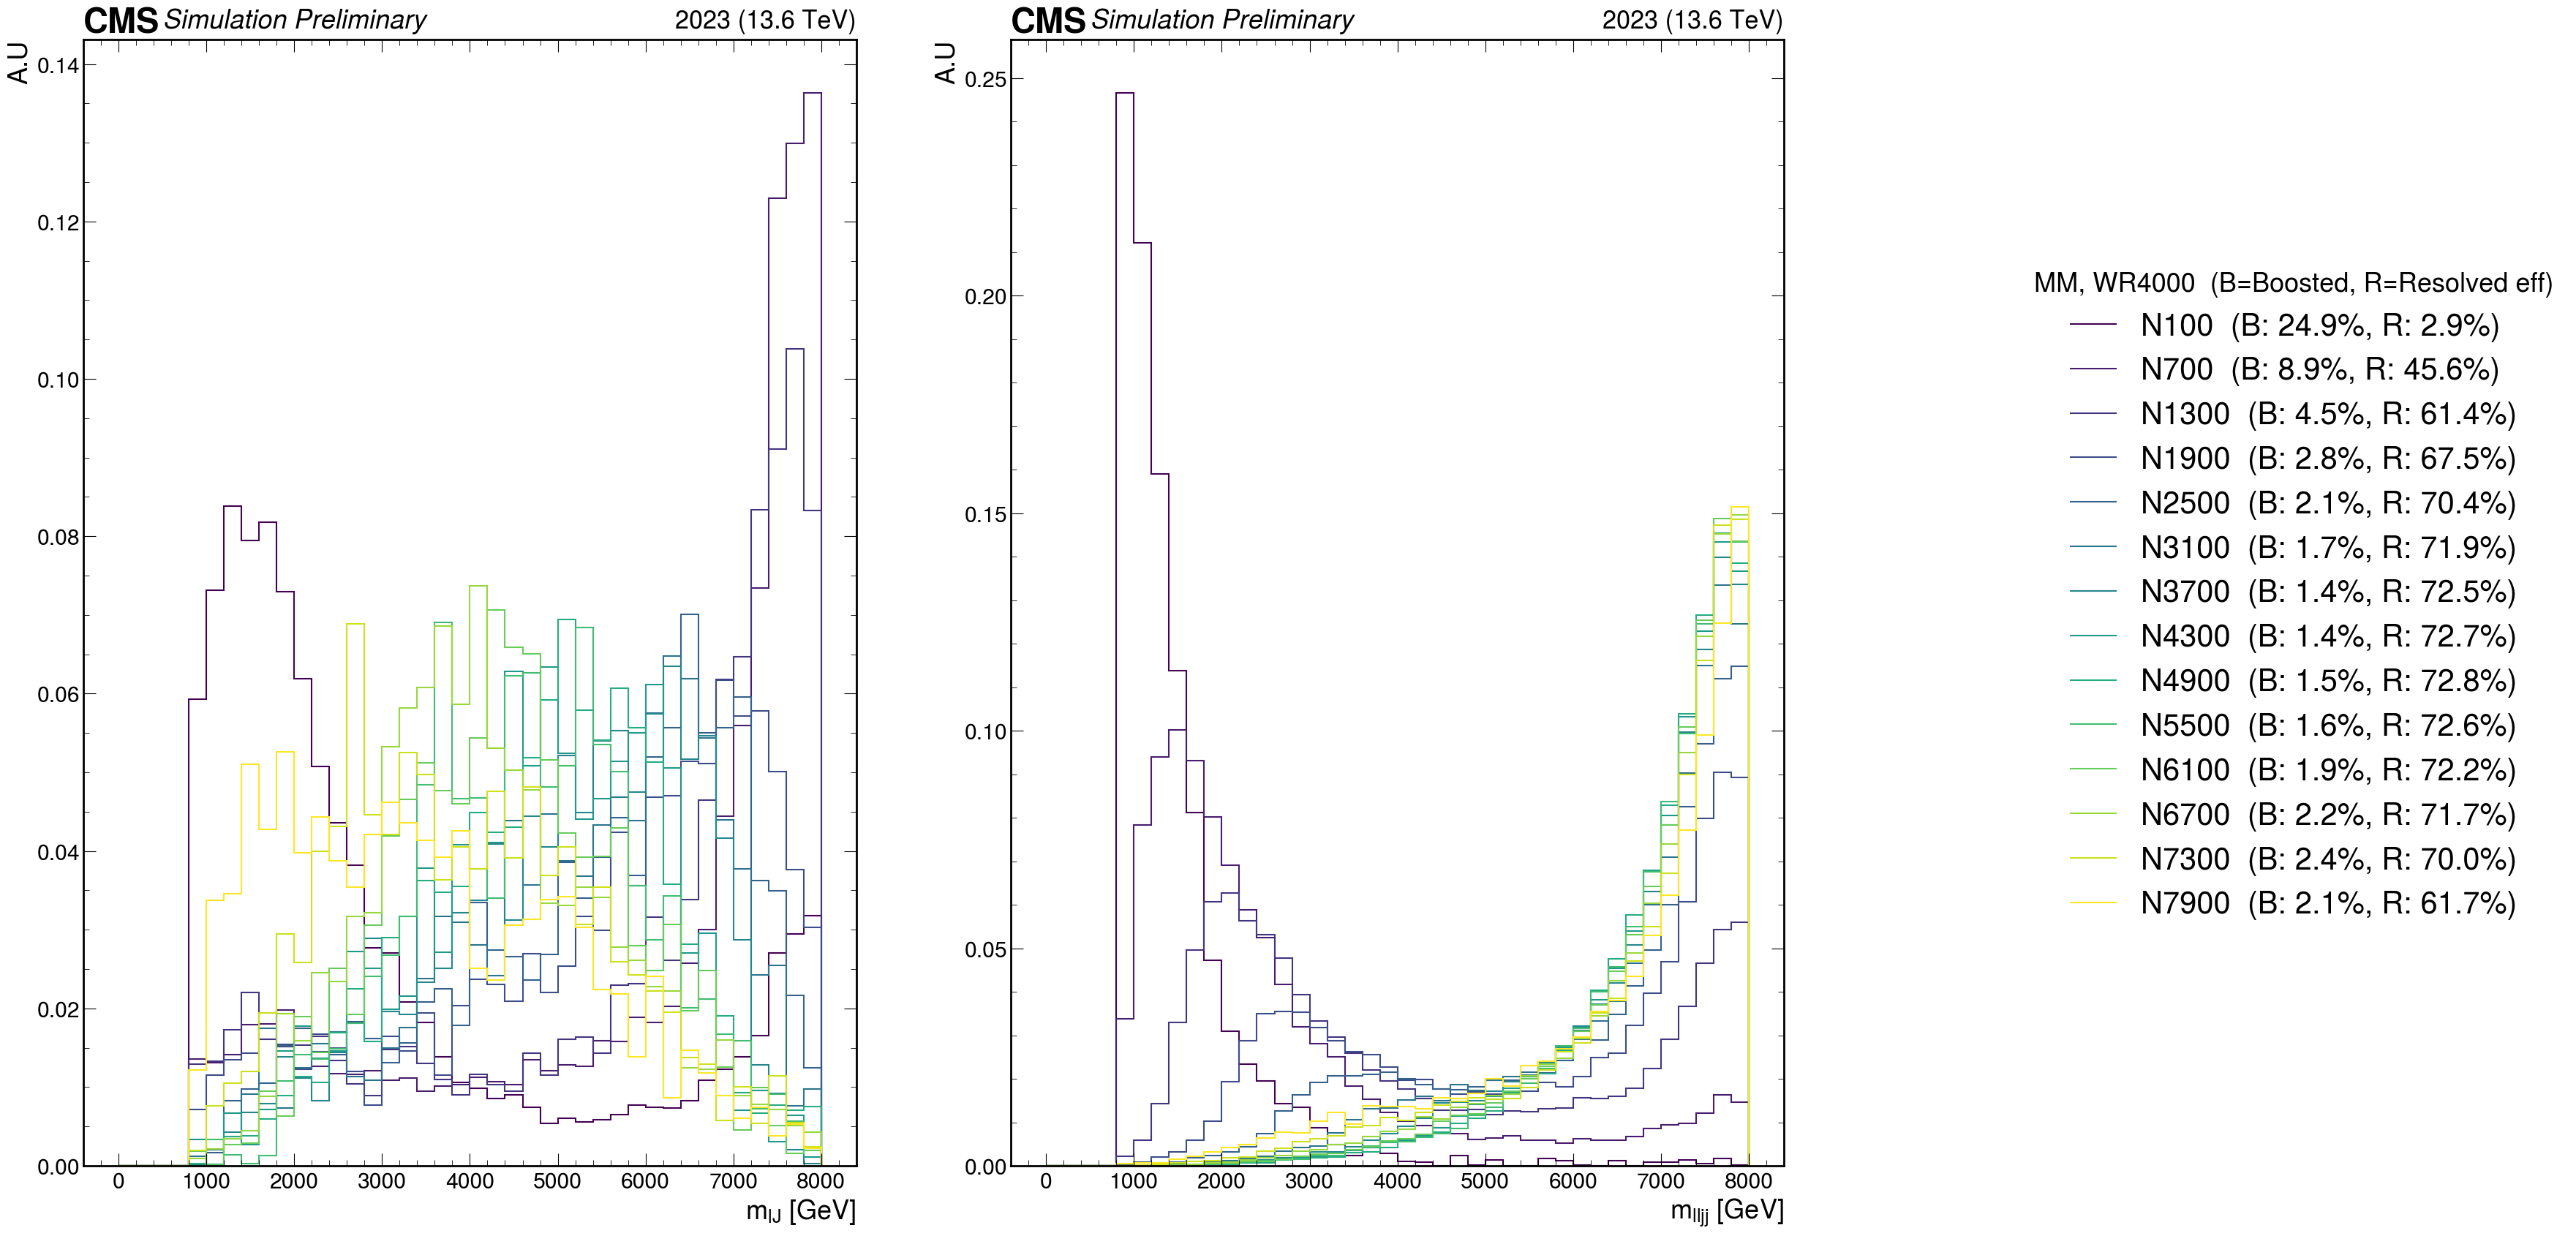

In [51]:
import json
import re
from pathlib import Path

import uproot
import hist
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import mplhep as hep

hep.style.use("CMS")

base_dir = "/gv0/Users/achihwan/SKNanoOutput/Reproduce20_002_copy/2023"
n_values = range(100, 8000, 600)
WR_FIXED = 8000

cmap = plt.cm.viridis
colors_arr = cmap(np.linspace(0, 1, len(n_values)))

# ---- efficiency 추출 (cutflow 기반) ----
boosted_hist_candidates = [
    'Central/Cutflow_for_Boosted_SR',
]
resolved_hist_candidates = [
    'Central/Cutflow_for_Resolved_SR',
    'Central/Cutflow_for_reseolved_SR',
]

def extract_efficiency_from_cutflow(root_path, hist_candidates, use_penultimate_bin=False):
    with uproot.open(root_path) as root_file:
        hist_name = next((name for name in hist_candidates if name in root_file), None)
        if hist_name is None:
            return np.nan

        values = root_file[hist_name].values(flow=False)
        if len(values) < 2:
            return np.nan

        second_bin = float(values[1])
        numerator_bin = float(values[-2] if use_penultimate_bin else values[-1])
        return np.nan if second_bin <= 0 else numerator_bin / second_bin

def get_eff(n, region):
    """N별 root 파일에서 boosted/resolved efficiency를 직접 읽는다."""
    fpath = f"{base_dir}/WR{WR_FIXED}N{n}MM.root"
    try:
        if region == "boosted":
            return extract_efficiency_from_cutflow(fpath, boosted_hist_candidates, use_penultimate_bin=True)
        else:
            return extract_efficiency_from_cutflow(fpath, resolved_hist_candidates)
    except (FileNotFoundError, OSError):
        return np.nan

def make_label(n):
    eff_b = get_eff(n, "boosted")
    eff_r = get_eff(n, "resolved")
    b_str = "-" if np.isnan(eff_b) else f"{eff_b*100:.1f}%"
    r_str = "-" if np.isnan(eff_r) else f"{eff_r*100:.1f}%"
    return f"N{n}  (B: {b_str}, R: {r_str})"

# ---- plot ----
def draw_panel(ax, branch, xlabel):
    for n, color in zip(n_values, colors_arr):
        fpath = f"{base_dir}/WR{WR_FIXED}N{n}MM.root"

        f = uproot.open(fpath)
        h = f[branch].to_hist()
        h_rb = h[::hist.rebin(200)]

        vals  = h_rb.values()
        edges = h_rb.axes[0].edges
        integral = vals.sum()

        if integral == 0:
            print(f"skip N{n}: empty histogram ({branch})")
            continue

        vals_norm = vals / integral

        hep.histplot(
            vals_norm,
            bins=edges,
            ax=ax,
            histtype="step",
            color=mcolors.to_hex(color),
            linewidth=1.5,
            label=make_label(n),
        )

    hep.cms.label("Preliminary", data=False, year=2023, com=13.6, ax=ax)
    ax.set_xlabel(xlabel)
    ax.set_ylabel("A.U")


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(30, 20))

draw_panel(ax1, "Central/SR_Boosted_MM_mlljj",  r"$m_{lJ}$ [GeV]")
draw_panel(ax2, "Central/SR_Resolved_MM_mlljj", r"$m_{lljj}$ [GeV]")

handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    loc="center left",
    bbox_to_anchor=(1.0, 0.5),
    ncol=1,
    fontsize=30,
    title="MM, WR4000  (B=Boosted, R=Resolved eff)",
)

fig.savefig(
    "SR_MM_norm_scan_boosted_resolved_eff.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()